## Import Libraries

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 

## Initialize Inputs

In [2]:
X = np.array([
    [1.0,1.0],
    [1.5,2.0],
    [3.0,4.0],
    [5.0,7.0],
    [3.5,5.0],
    [4.5,5.0],
    [3.5,4.5]
])

## K-Means

In [8]:
class KMeans:
    def __init__(self, X, K, verbose = True):
        self.X = X
        self.K = K
        self.verbose = verbose

    def initialize_centroids(self):
        self.centroids = np.random.default_rng().choice(self.X, self.K, replace=False, axis=0)
        if self.verbose:
            print("Initial Centroids : ", self.centroids)
        return self.centroids

    def find_closest_centroid(self, point, centroids):
        distances = np.linalg.norm(centroids - point, axis=1)
        return np.argmin(distances)

    def assign_cluster(self):
        idx = []
        for point in self.X:
            cluster = self.find_closest_centroid(point, self.centroids)
            idx.append(cluster)
        self.idx = np.array(idx)       
        return self.idx

    def compute_centroids(self):
        new_centroids = []
        for k in range(self.K):
            points = self.X[self.idx == k]
            centroid = np.mean(points, axis=0)
            new_centroids.append(centroid)
        self.new_centroids = np.array(new_centroids)
        return self.new_centroids

    def compute_cost(self):
        m = len(self.X)
        total = 0
        for i in range(m):
            centroid = self.new_centroids[self.idx[i]]
            total += np.sum((self.X[i] - centroid) ** 2)
        return total / m

    def run_kmeans(self, max_iters=100, plot = True):
        self.initialize_centroids()

        for i in range(max_iters):
            self.assign_cluster()
            new_centroids = self.compute_centroids()
            if np.allclose(new_centroids, self.centroids):
                break
            self.centroids = new_centroids          

        if self.verbose:
            print("Final centroids:", self.centroids)
            print("Final clusters:", self.idx)

        if plot:
            plt.scatter(self.X[:, 0], self.X[:, 1], c=self.idx, s=60, cmap='tab10')
            plt.scatter(self.centroids[:, 0], self.centroids[:, 1], marker='X', color='red', s=200)
            plt.xlabel("X")
            plt.ylabel("Y")
            plt.show()

In [9]:
km = KMeans(X, K = 3)

Initial Centroids :  [[1.5 2. ]
 [4.5 5. ]
 [5.  7. ]]
Final centroids: [[1.25  1.5  ]
 [3.625 4.625]
 [5.    7.   ]]
Final clusters: [0 0 1 2 1 1 1]


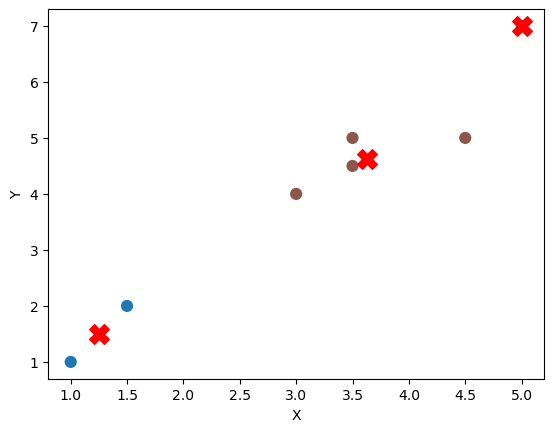

In [10]:
km.run_kmeans()

## K-Means++

In [11]:
class KMeansPlusPlus(KMeans):
    def initialize_centroids(self): 
        first_idx = np.random.default_rng().choice(len(self.X))
        if self.verbose:
            print("First Initial Centroid : ", self.X[first_idx])
        centroids = [self.X[first_idx]]

        for _ in range(1, self.K):
            centroids_array = np.array(centroids)
            sq_distances = np.array([np.min(np.linalg.norm(centroids_array - point, axis=1))**2 for point in self.X])
            probs = sq_distances / sq_distances.sum()
            next_idx = np.random.default_rng().choice(len(self.X), p=probs)
            centroids.append(self.X[next_idx])

        self.centroids = np.array(centroids)
        return self.centroids

In [12]:
KM = KMeansPlusPlus(X, K = 2)

First Initial Centroid :  [3. 4.]
Final centroids: [[3.9  5.1 ]
 [1.25 1.5 ]]
Final clusters: [1 1 0 0 0 0 0]


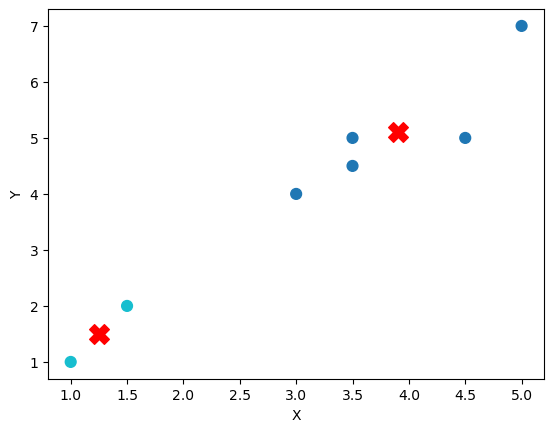

In [14]:
KM.run_kmeans()

## Elbow Method

In [18]:
def elbow_method(X, k_range=range(2, 6), max_iters=200, method = "Kmeans"):
    costs = []
    for K in k_range:
        if method == "kmeans" or method == "Kmeans" or method == "KMeans" or method == "KMEANS":
            km = KMeans(X, K, verbose = False)  
        else:
            km = KMeansPlusPlus(X, K, verbose = False)
        km.run_kmeans(max_iters=max_iters, plot = False)
        cost = km.compute_cost()
        costs.append(cost)

    plt.plot(list(k_range), costs, marker='o')
    plt.xlabel("K")
    plt.ylabel("Cost")
    plt.show()

    return costs

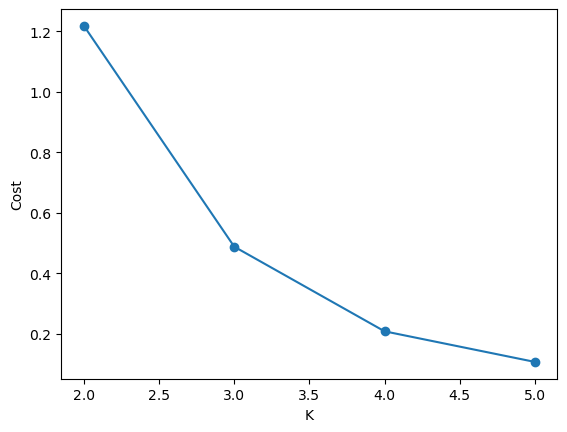

[np.float64(1.2178571428571427),
 np.float64(0.4880952380952381),
 np.float64(0.20833333333333331),
 np.float64(0.10714285714285714)]

In [16]:
elbow_method(X, method = "kmeans")

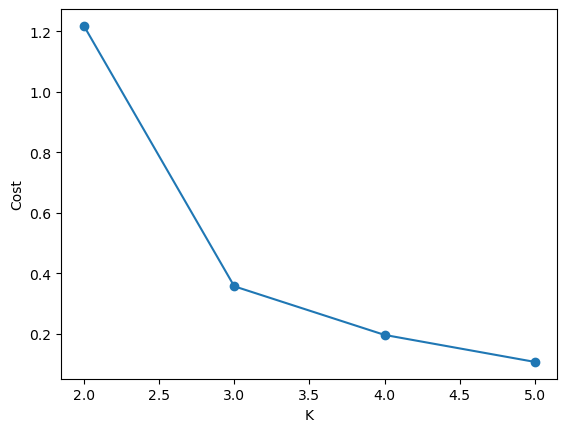

[np.float64(1.2178571428571427),
 np.float64(0.35714285714285715),
 np.float64(0.19642857142857142),
 np.float64(0.10714285714285714)]

In [17]:
elbow_method(X, method = "kmeans++")